# Feature Transform

IXPLORE accepts a kernel function $\varphi$ that transforms each 2D latent position into a feature vector before the per-item logistic regression. The default is the identity (linear features); a polynomial kernel adds the squared coordinates $(x^2, y^2)$, and a random Fourier features (RFF) kernel projects the position into a high-dimensional cosine basis to approximate an RBF kernel.

**Research question:** Do non-linear features improve fit and imputation while remaining visually interpretable?

All experiments use PCA initialization, default $\tau^2 = 0.25$, and the iteration count $T=10$, with 5 seeds per sparsity > 0.

In [1]:
import sys; sys.path.insert(0, "../..")
import logging; logging.getLogger("ixplore").setLevel(logging.WARNING)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.data import DATASET_DIRS
from src.visualization import apply_defaults, figsize

apply_defaults()

DATASET = "smartvote_2023"
RESULTS_DIR = Path(f"../../results/{DATASET}/feature_effect")
MODELS_DIR = RESULTS_DIR / "models"
BASELINE_DIR = Path(f"../../results/{DATASET}/baseline")
FIGURES_DIR = Path("../../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
data_dir = DATASET_DIRS[DATASET]

KERNELS = ["linear", "polynomial", "rff"]
KERNEL_LABELS = {"linear": "Linear", "polynomial": "Polynomial", "rff": "RFF"}
KERNEL_COLORS = {"linear": "C0", "polynomial": "C1", "rff": "C2"}

train = pd.read_csv(RESULTS_DIR / "train_metrics.csv")
test = pd.read_csv(RESULTS_DIR / "test_metrics.csv")

print(f"train: {train.shape}, test: {test.shape}")
print(f"cols: {list(train.columns)}")

train: (48, 13), test: (48, 11)
cols: ['fit_mae', 'fit_accuracy', 'fit_rmse', 'impute_mae', 'impute_accuracy', 'impute_rmse', 'spread', 'boundary', 'distortion_mean', 'distortion_std', 'model', 'sparsity', 'seed']


## Do non-linear kernels improve fit and imputation?

Compare the three IXPLORE kernels (linear, polynomial, RFF) against each other and against all baseline algorithms on fit and impute MAE / accuracy, on both train and test reactions, across sparsity levels.

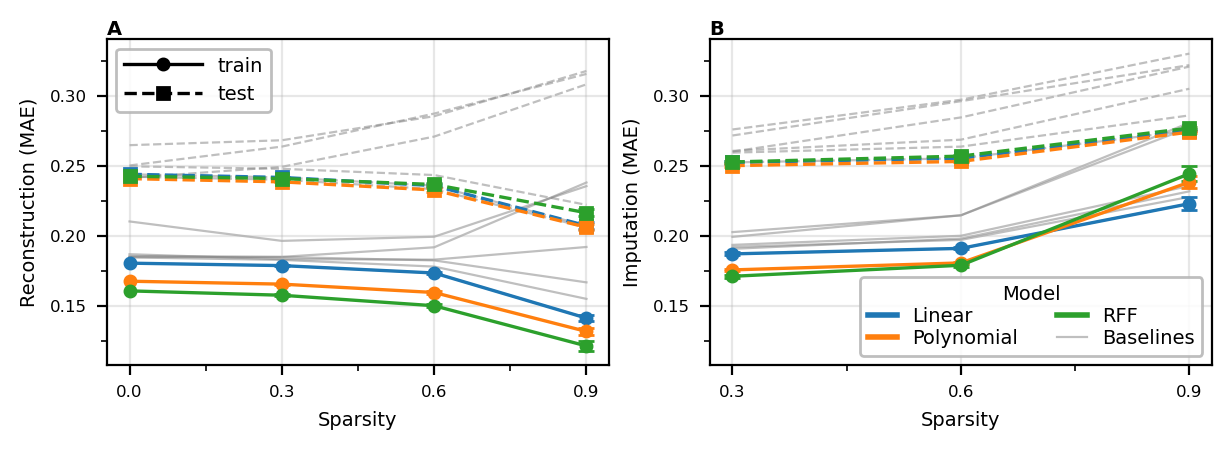

In [2]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Toggle the comparison metric: "mae" or "accuracy".
METRIC = "mae"
METRIC_LABEL = {"mae": "MAE", "accuracy": "Accuracy"}[METRIC]
SUBSET_MODELS = ['pca-logistic', 'vae-2layer', 'umap-logistic', 'ideal', 'lsirm', 'ixplore']

baseline_train_frames, baseline_test_frames = [], []
for alg in SUBSET_MODELS:
    alg_dir = BASELINE_DIR / alg
    baseline_train_frames.append(pd.read_csv(alg_dir / "train_metrics.csv"))
    te = alg_dir / "test_metrics.csv"
    if te.exists():
        baseline_test_frames.append(pd.read_csv(te))
all_baseline_train = pd.concat(baseline_train_frames, ignore_index=True)
all_baseline_test = pd.concat(baseline_test_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=figsize(width_frac=1.0, aspect=0.35), sharey=True)

def _baseline_line(df, ax, metric, linestyle):
    stats = df.groupby("sparsity")[metric].mean().reset_index()
    ax.plot(stats["sparsity"], stats[metric],
            color="grey", linestyle=linestyle, linewidth=0.8, alpha=0.5, zorder=0)

def _kernel_errorbar(df, ax, metric, color, linestyle, marker):
    stats = df.groupby("sparsity")[metric].agg(["mean", "std"]).reset_index()
    ax.errorbar(stats["sparsity"], stats["mean"], yerr=stats["std"],
                marker=marker, color=color, linestyle=linestyle, zorder=3)

fit_col = f"fit_{METRIC}"
impute_col = f"impute_{METRIC}"

for alg in SUBSET_MODELS:
    btr = all_baseline_train[all_baseline_train["model"] == alg]
    bte = all_baseline_test[all_baseline_test["model"] == alg]
    _baseline_line(btr, axes[0], fit_col, "-")
    _baseline_line(btr, axes[1], impute_col, "-")
    if not bte.empty:
        _baseline_line(bte, axes[0], fit_col, "--")
        _baseline_line(bte, axes[1], impute_col, "--")

for kernel in KERNELS:
    ktr = train[train["model"] == kernel]
    kte = test[test["model"] == kernel]
    color = KERNEL_COLORS[kernel]
    _kernel_errorbar(ktr, axes[0], fit_col, color, "-", "o")
    _kernel_errorbar(ktr, axes[1], impute_col, color, "-", "o")
    if not kte.empty:
        _kernel_errorbar(kte, axes[0], fit_col, color, "--", "s")
        _kernel_errorbar(kte, axes[1], impute_col, color, "--", "s")

axes[0].set_ylabel(f"Reconstruction ({METRIC_LABEL})")
axes[1].set_ylabel(f"Imputation ({METRIC_LABEL})")
for ax in axes:
    ax.set_xlabel("Sparsity")
    ax.xaxis.set_major_locator(MultipleLocator(0.3))
    ax.xaxis.set_minor_locator(MultipleLocator(0.15))
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.025))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_tick_params(labelleft=True)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="train"),
    Line2D([0], [0], color="black", linestyle="--", marker="s", label="test"),
]
axes[0].legend(handles=style_handles, loc="best", handlelength=4)

color_handles = (
    [Line2D([0], [0], color=KERNEL_COLORS[k], lw=2, label=KERNEL_LABELS[k]) for k in KERNELS]
    + [Line2D([0], [0], color="grey", lw=0.8, alpha=0.5, label="Baselines")]
)
axes[1].legend(handles=color_handles, loc="lower right", title="Model",
               handlelength=1.5, ncols=2, labelspacing=0.15, facecolor="white")
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95], w_pad=0.7)
fig.savefig(FIGURES_DIR / f"kernel_comparison_{METRIC}_{DATASET}.pdf")
plt.show()

In [3]:
# Paired one-sided t-test: do polynomial / RFF beat linear?
# Pairs are matched on (sparsity, seed) so within-pair variance is removed.
from scipy import stats

def paired_test(df, metric, kernel, alternative):
    pivot = (df[df["model"].isin(["linear", kernel])]
             .pivot_table(values=metric, index=["sparsity", "seed"], columns="model"))
    pivot = pivot.dropna()
    diff = pivot[kernel] - pivot["linear"]
    t = stats.ttest_rel(pivot[kernel], pivot["linear"], alternative=alternative)
    return {
        "n_pairs": len(diff),
        "mean_diff": diff.mean(),
        "std_diff": diff.std(),
        "t": t.statistic,
        "p": t.pvalue,
    }

# For MAE: kernel < linear means lower error, so alternative = "less".
# For accuracy: kernel > linear means higher accuracy, so alternative = "greater".
configs = [
    ("train", train, "fit_mae", "less"),
    ("train", train, "impute_mae", "less"),
    ("test",  test,  "fit_mae", "less"),
    ("test",  test,  "impute_mae", "less"),
    ("train", train, "fit_accuracy", "greater"),
    ("train", train, "impute_accuracy", "greater"),
    ("test",  test,  "fit_accuracy", "greater"),
    ("test",  test,  "impute_accuracy", "greater"),
]

rows = []
for split, df, metric, alt in configs:
    for kernel in ("polynomial", "rff"):
        r = paired_test(df, metric, kernel, alt)
        r.update({"split": split, "metric": metric, "kernel_vs_linear": kernel,
                  "alt": alt})
        rows.append(r)

result = pd.DataFrame(rows)[["split", "metric", "kernel_vs_linear", "alt",
                              "n_pairs", "mean_diff", "std_diff", "t", "p"]]
print(result.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

split          metric kernel_vs_linear     alt  n_pairs  mean_diff  std_diff        t      p
train         fit_mae       polynomial    less       16    -0.0123    0.0024 -20.4872 0.0000
train         fit_mae              rff    less       16    -0.0214    0.0023 -37.5264 0.0000
train      impute_mae       polynomial    less       15    -0.0022    0.0129  -0.6459 0.2644
train      impute_mae              rff    less       15    -0.0022    0.0175  -0.4900 0.3159
 test         fit_mae       polynomial    less       16    -0.0025    0.0011  -9.2116 0.0000
 test         fit_mae              rff    less       16     0.0028    0.0046   2.4554 0.9866
 test      impute_mae       polynomial    less       15    -0.0019    0.0009  -8.5786 0.0000
 test      impute_mae              rff    less       15     0.0012    0.0009   5.4114 1.0000
train    fit_accuracy       polynomial greater       16     0.0149    0.0046  12.8833 0.0000
train    fit_accuracy              rff greater       16     0.0228    

## Do curved decision boundaries remain visually interpretable?

**Decision-boundary plots** for one example item, one panel per kernel — to check whether candidates align with the predicted-yes regions.

### Decision boundaries on the most kernel-discriminating item

Pick the item whose accuracy range across the three kernels is largest (`SELECTION_METRIC` toggles to `"mae"`) and show the predicted-probability surface for that item under each kernel.

Selection metric: accuracy
Item with largest spread across kernels: 32263 (idx 49)
Question (EN): Should it be possible to hold a referendum on federal spending above a certain amount (optional financial referendum)?
MAE per kernel:      {'linear': np.float64(0.35), 'polynomial': np.float64(0.258), 'rff': np.float64(0.215)}
Accuracy per kernel: {'linear': np.float64(0.568), 'polynomial': np.float64(0.767), 'rff': np.float64(0.803)}

Candidate dot colors — actual response on this item, mapped through ixplore_cmap
  total candidates plotted: 1029  (1029 answered, 0 NaN→grey)
  response = 0.00  →  309 candidates
  response = 0.25  →  178 candidates
  response = 0.75  →  210 candidates
  response = 1.00  →  332 candidates


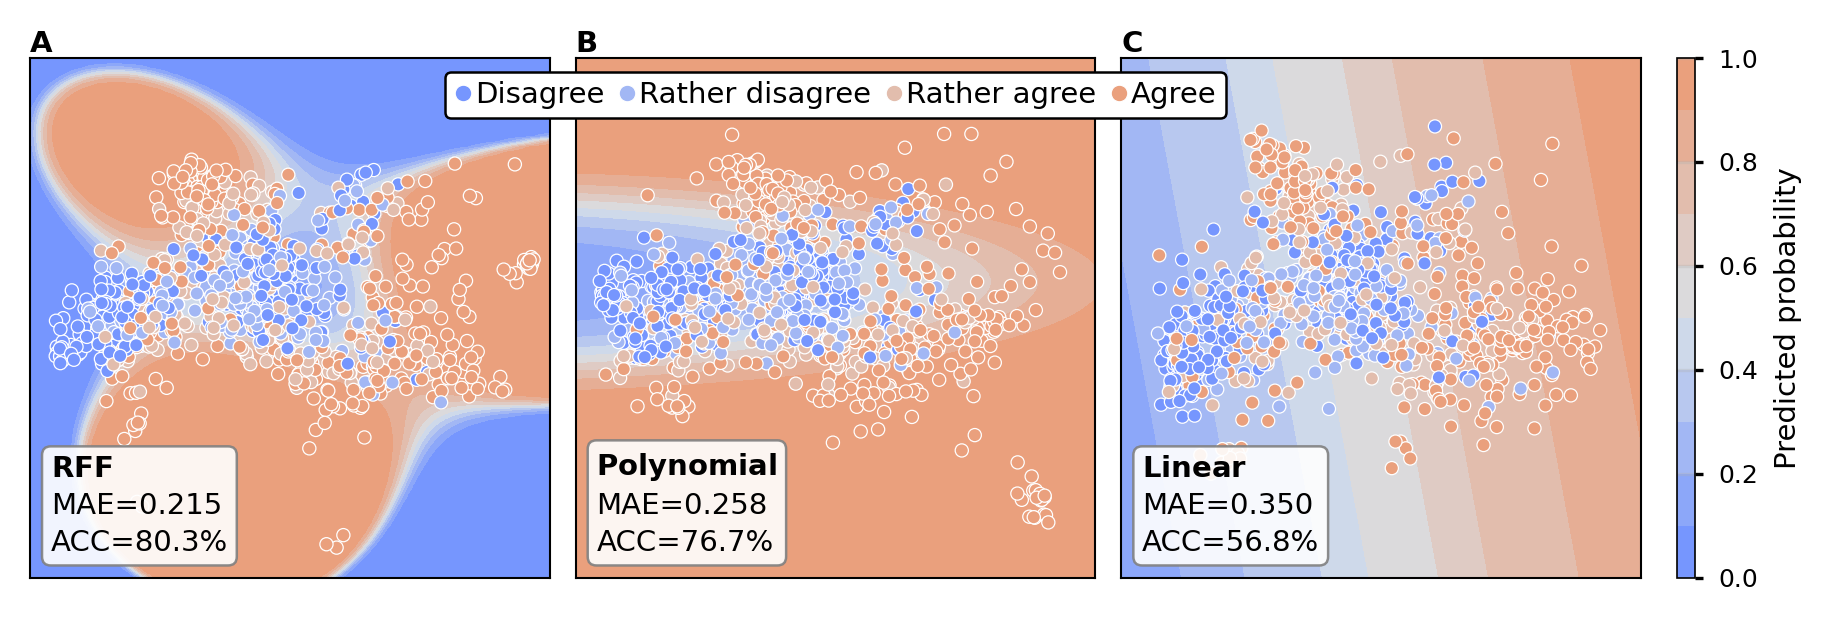

In [4]:
from ixplore.visualization import colormap as ixplore_cmap
from matplotlib import cm
from matplotlib.colors import Normalize
from src.models import IXPLOREModel
from src.data import load_dataset

dataset = load_dataset(DATASET)
reactions = dataset.train_reactions
models = {name: IXPLOREModel.load(MODELS_DIR / f"{name}_sp_0.0") for name in KERNELS}

# Metric used to pick the most kernel-discriminating item.
# "accuracy" or "mae" — picks the item whose range across kernels is largest.
SELECTION_METRIC = "accuracy"

# Smartvote 5-point agreement scale.
AGREEMENT_LABELS = {
    0.0: "Disagree",
    0.25: "Rather disagree",
    0.5: "Neutral",
    0.75: "Rather agree",
    1.0: "Agree",
}

statements = pd.read_csv(data_dir / "statements.csv").set_index("ID_question")

# Per-item MAE and accuracy for each kernel, on the embedding it was trained on.
per_item_mae, per_item_acc = {}, {}
preds_by_kernel, embeddings_by_kernel = {}, {}
for name, model in models.items():
    emb = model.get_embedding().values
    preds = model.predict(emb)
    actual = reactions.values.astype(float)
    mask = ~np.isnan(actual)
    abs_err = np.where(mask, np.abs(actual - preds), 0.0)
    correct = np.where(mask, (preds >= 0.5) == (actual >= 0.5), 0.0)
    counts = mask.sum(axis=0)
    per_item_mae[name] = np.where(counts > 0, abs_err.sum(axis=0) / np.maximum(counts, 1), np.nan)
    per_item_acc[name] = np.where(counts > 0, correct.sum(axis=0) / np.maximum(counts, 1), np.nan)
    preds_by_kernel[name] = preds
    embeddings_by_kernel[name] = emb

mae_matrix = pd.DataFrame(per_item_mae, index=reactions.columns)
acc_matrix = pd.DataFrame(per_item_acc, index=reactions.columns)

selection_source = {"accuracy": acc_matrix, "mae": mae_matrix}[SELECTION_METRIC]
score_range = selection_source.max(axis=1) - selection_source.min(axis=1)
selected_item = score_range.idxmax()
selected_idx = list(reactions.columns).index(selected_item)
question_text = statements.loc[int(selected_item), "question_EN"]

actual_item = reactions.iloc[:, selected_idx].values
mask_item = ~np.isnan(actual_item)
value_counts = pd.Series(actual_item[mask_item]).value_counts().sort_index()

print(f"Selection metric: {SELECTION_METRIC}")
print(f"Item with largest spread across kernels: {selected_item} (idx {selected_idx})")
print(f"Question (EN): {question_text}")
print(f"MAE per kernel:      {dict(mae_matrix.loc[selected_item].round(3))}")
print(f"Accuracy per kernel: {dict(acc_matrix.loc[selected_item].round(3))}")
print()
print("Candidate dot colors — actual response on this item, mapped through ixplore_cmap")
print(f"  total candidates plotted: {len(actual_item)}  ({mask_item.sum()} answered, {(~mask_item).sum()} NaN→grey)")
for v, n in value_counts.items():
    print(f"  response = {v:.2f}  →  {n} candidates")

resolution = 100
grid_x = np.linspace(-1, 1, resolution)
grid_y = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# 3 square panels at textwidth: ~2 in / panel, plus padding.
fig, axes = plt.subplots(1, 3, figsize=figsize(width_frac=1.0, aspect=0.32))

# Local kernel order for this figure (reversed relative to the global KERNELS).
panel_kernels = list(reversed(KERNELS))

for ax, name in zip(axes, panel_kernels):
    model = models[name]
    emb = embeddings_by_kernel[name]
    preds_grid = model.predict(grid_points)
    zz = preds_grid[:, selected_idx].reshape(xx.shape)
    # Flip across the y-axis: mirror both the contour grid and the embedding x.
    ax.contourf(-xx, yy, zz, levels=20, cmap=ixplore_cmap, vmin=0, vmax=1)

    candidate_colors = np.array([ixplore_cmap(v) if not np.isnan(v) else (0.6, 0.6, 0.6, 1.0)
                                  for v in actual_item.astype(float)])
    ax.scatter(-emb[:, 0], emb[:, 1], c=candidate_colors, s=10,
               edgecolors="white", linewidths=0.3, zorder=2)

    item_preds = preds_by_kernel[name][:, selected_idx]
    mae = np.mean(np.abs(actual_item[mask_item] - item_preds[mask_item]))
    acc = np.mean((item_preds[mask_item] >= 0.5) == (actual_item[mask_item] >= 0.5))

    bbox = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9,
                edgecolor="0.5", linewidth=0.6)
    ax.text(0.04, 0.04,
            f"$\\bf{{{KERNEL_LABELS[name]}}}$\nMAE={mae:.3f}\nACC={acc * 100:.1f}%",
            transform=ax.transAxes, ha="left", va="bottom",
            linespacing=1.4, bbox=bbox)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.grid(False)

# Shared agreement-value legend at top of the middle panel.
agreement_values = sorted(value_counts.index.tolist())
agreement_handles = [plt.Line2D([0], [0], marker="o", color="w",
                                markerfacecolor=ixplore_cmap(v), markersize=4,
                                markeredgecolor="white", markeredgewidth=0.3,
                                label=AGREEMENT_LABELS.get(round(v, 2), f"{v:.2f}"))
                     for v in agreement_values]
leg = axes[1].legend(handles=agreement_handles, loc="upper center",
                     ncol=len(agreement_values), fontsize=7,
                     handlelength=0.6, handletextpad=0.1,
                     columnspacing=0.5, labelspacing=0.2,
                     borderpad=0.3, framealpha=1.0, facecolor="white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(0.6)
axes[1].set_zorder(axes[0].get_zorder() + 1)
axes[1].set_zorder(axes[2].get_zorder() + 1)
axes[1].patch.set_visible(False)
leg.set_zorder(20)

fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.text(-0,1, 'C', va='bottom', ha='left', weight='bold', transform=axes[2].transAxes)
fig.subplots_adjust(top=0.95, bottom=0.005, left=0.005, right=0.9, wspace=0.05)

# Thin shared colorbar matched to the actual vertical extent of panel C.
panel_bbox = axes[2].get_position()
cbar_ax = fig.add_axes([0.92, panel_bbox.y0, 0.01, panel_bbox.height])
cbar = fig.colorbar(cm.ScalarMappable(norm=Normalize(0, 1), cmap=ixplore_cmap),
                    cax=cbar_ax)
cbar.set_label("Predicted probability", fontsize=7)
cbar.ax.tick_params(labelsize=6, length=2)
cbar.outline.set_linewidth(0.4)

fig.savefig(FIGURES_DIR / f"kernels_visual_{DATASET}.pdf")
plt.show()